In [4]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import scipy.stats as stats
Planet_data= pd.read_csv('Data/planets.csv', comment='#')
from scipy import constants
k_b = constants.physical_constants['Boltzmann constant'][0]

In [5]:

array_1 = pd.read_csv('', comment='#')

Feature_heights     = array_1.iloc[:, 3]
Feature_heights_err = array_1.iloc[:, 4]

# Signal-to-noise: height / error (higher = better detected feature)
height_over_error = Feature_heights / Feature_heights_err

T_eq       = array_1.iloc[:, 1]
T_eq_error = array_1.iloc[:, 2]

Bin_number  = 8
good_planets = []  # Fix: was referencing good_planets_index which didn't exist

for i in range(Bin_number):
    lower = np.percentile(T_eq, i * 100 / Bin_number)
    upper = np.percentile(T_eq, (i + 1) * 100 / Bin_number)

    # Fix: use >= for first bin so minimum value isn't excluded
    if i == 0:
        mask = (T_eq >= lower) & (T_eq <= upper)
    else:
        mask = (T_eq > lower) & (T_eq <= upper)

    subset = height_over_error[mask]

    # Sort descending so best signal-to-noise is first
    ordered_subset = subset.sort_values(ascending=False)

    # Take the top planet in this bin (change to [:N] for top N)
    top_in_bin = ordered_subset.index[0] if len(ordered_subset) > 0 else None

    if top_in_bin is not None:
        good_planets.append(top_in_bin)

    # Fix: print the actual top value instead of empty {}
    top_val = ordered_subset.iloc[0] if len(ordered_subset) > 0 else None
    print(f'Bin {i}: Range {lower:.1f} < T < {upper:.1f} | Planets {good_planets}')

print('\nTop planet indices per bin:', good_planets)
print('Top planet rows:')
print(array_1.loc[good_planets])

print(min(array_1.iloc[:, 3]))

plt.figure(figsize=(14, 6))
plt.errorbar(array_1.iloc[:, 1], array_1.iloc[:, 3], array_1.iloc[:, 4],
             fmt='o', markersize=5, color='teal', ecolor='black', capsize=2, label='Feature bin')
plt.xlabel('Equilibrium Temperature (K)', fontsize=14)
plt.ylabel('$Feature depth$', fontsize=14)
plt.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.8)
plt.grid(True, which='minor', alpha=0.15, linestyle=':', linewidth=0.5)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: ''

Bin 0: 206.3K - 278.1K | Best planets: ['LHS 1140 b', 'K2-18 b']
Bin 1: 278.1K - 349.9K | Best planets: ['TOI-1468 c', 'TOI-1470 c']
Bin 2: 349.9K - 421.8K | Best planets: ['L 98-59 d', 'TOI-4438 b']
Bin 3: 421.8K - 493.6K | Best planets: ['TOI-2443 b', 'TOI-178 g']
Bin 4: 493.6K - 565.4K | Best planets: ['GJ 1214 b', 'HD 191939 d']
Bin 5: 565.4K - 637.3K | Best planets: ['GJ 3090 b', 'TOI-178 d']
Bin 6: 637.3K - 709.1K | Best planets: ['K2-138 f', 'HD 42813 b']
Bin 7: 709.1K - 780.9K | Best planets: ['TOI-561 c', 'HD 135694 b']
Bin 8: 780.9K - 852.7K | Best planets: ['TOI-1422 b', 'TOI-1260 b']
Bin 9: 852.7K - 924.6K | Best planets: ['TOI-1799 b', 'K2-138 d']
Bin 10: 924.6K - 996.4K | Best planets: ['TOI-1136 c', 'TOI-969 b']
[206.2954597930245, 278.1218140530897, 349.94816831315495, 421.7745225732201, 493.6008768332854, 565.4272310933505, 637.2535853534158, 709.079939613481, 780.9062938735462, 852.7326481336115, 924.5590023936767]
['LHS 1140 b', 'K2-18 b', 'TOI-1468 c', 'TOI-1470 c',

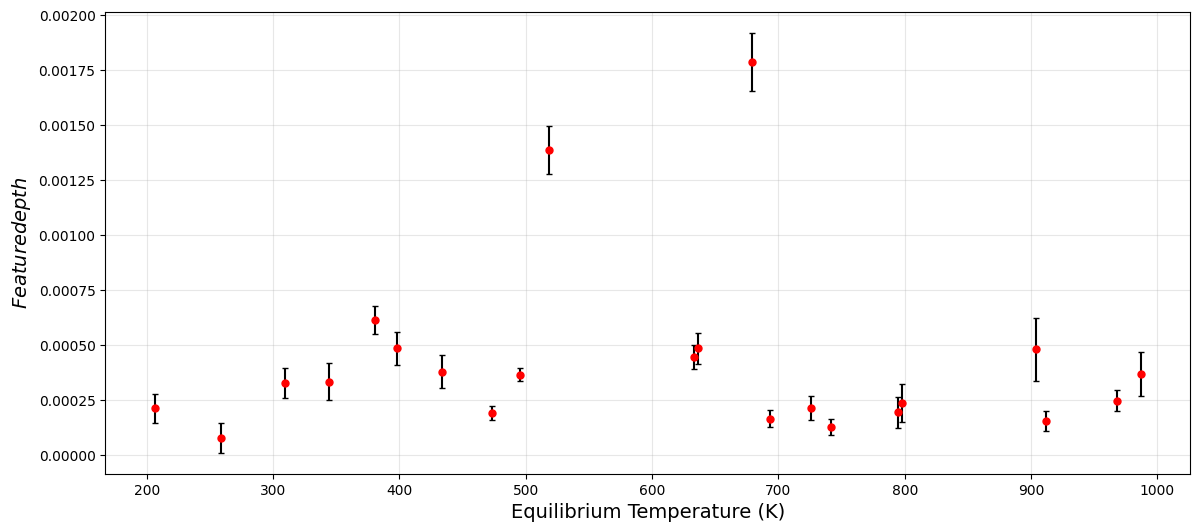

In [10]:
array_1 = pd.read_csv(r'C:\Users\Miles\Documents\group studies\Group-Studies---Exoplanets\Code\Data\results\results_2026_02_20__16_44.csv', comment='#')

Feature_heights     = array_1.iloc[:, 3]
Feature_heights_err = array_1.iloc[:, 4]
height_over_error   = Feature_heights / Feature_heights_err

T_eq       = array_1.iloc[:, 1]
T_eq_error = array_1.iloc[:, 2]

Bin_number   = 11
good_planets = []

N = 2  # Change this to however many top planets you want per bin
bin_edges = np.linspace(T_eq.min(), T_eq.max(), Bin_number + 1)
temps= []
for i in range(Bin_number):
    lower = bin_edges[i]
    upper = bin_edges[i + 1]

    if i == 0:
        mask = (T_eq >= lower) & (T_eq <= upper)
    else:
        mask = (T_eq > lower) & (T_eq <= upper)

    subset         = height_over_error[mask]
    ordered_subset = subset.sort_values(ascending=False)

    # Slice the top N (or fewer if the bin has less than N planets)
    top_n = ordered_subset.head(N)

    print(f'Bin {i}: {lower:.1f}K - {upper:.1f}K | Best planets: {[array_1.iloc[idx, 0] for idx in top_n.index]}')
    temps.append(float(lower))
    good_planets.extend(top_n.index.tolist())

print(temps)
print(array_1.iloc[good_planets,0].tolist())  # Print planet names for all good planets
plt.figure(figsize=(14, 6))
plt.errorbar(array_1.iloc[good_planets, 1], array_1.iloc[good_planets, 3], array_1.iloc[good_planets, 4],
             fmt='o', markersize=5, color='red', ecolor='black', capsize=2, label='Feature bin')
plt.xlabel('Equilibrium Temperature (K)', fontsize=14)
plt.ylabel('$Feature depth$', fontsize=14)
plt.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.8)
plt.grid(True, which='minor', alpha=0.15, linestyle=':', linewidth=0.5)
plt.show()


['GJ 1214 b', 'GJ 3090 b', 'K2-138 d', 'K2-138 f', 'K2-18 b', 'L 98-59 d', 'LHS 1140 b', 'TOI-1064 c', 'TOI-1136 c', 'TOI-1260 b', 'TOI-1422 b', 'TOI-1468 c', 'TOI-1758 b', 'TOI-1799 b', 'TOI-270 d', 'TOI-4438 b', 'TOI-521 b', 'TOI-561 c', 'TOI-969 b']


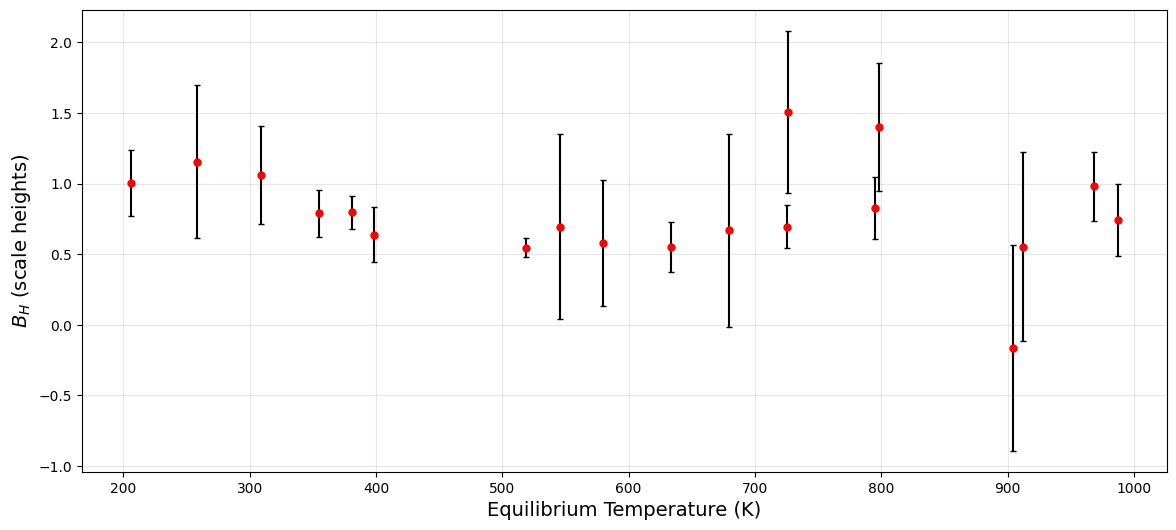

In [21]:
array_1= pd.read_csv('Data/results/results_2026_02_26__15_50.csv')

print(list(array_1['# File_Name']))
#array_1= array_1[mask]
plt.figure(figsize=(14,6))
plt.errorbar(array_1.iloc[:,1], array_1.iloc[:,5],array_1.iloc[:,6],fmt='o',markersize=5,
                     color='red', ecolor= 'black',capsize=2,label='Feature bin')
#plt.scatter(array_1[:,1], array_1[:,3])
#plt.ylim(-100,100)
plt.xlabel('Equilibrium Temperature (K)', fontsize=14)
plt.ylabel('$B_H$ (scale heights)', fontsize=14)
plt.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.8)
plt.grid(True, which='minor', alpha=0.15, linestyle=':', linewidth=0.5)

plt.show()

1.8715274620290514
-24.428005877900613


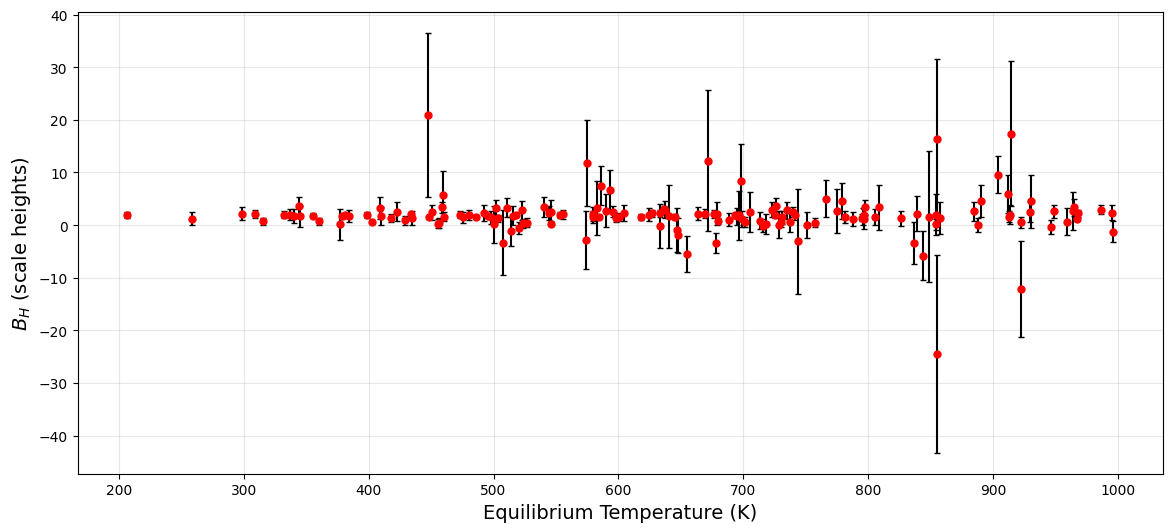

In [5]:
array_1= pd.read_csv(r'C:\Users\Miles\OneDrive\Documents\uni stuff\Year 3\Group studies\Group-Studies---Exoplanets\Code\Data\results_2026_02_20__16_44.csv', comment='#')
print(np.mean(array_1.iloc[:,5]))
#array_1= array_1[mask]
print(min(array_1.iloc[:,5]))
plt.figure(figsize=(14,6))
plt.errorbar(array_1.iloc[:,1], array_1.iloc[:,5],array_1.iloc[:,6],fmt='o',markersize=5,
                     color='red', ecolor= 'black',capsize=2,label='Feature bin')
#plt.scatter(array_1[:,1], array_1[:,3])
#plt.ylim(-100,100)
plt.xlabel('Equilibrium Temperature (K)', fontsize=14)
plt.ylabel('$B_H$ (scale heights)', fontsize=14)
plt.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.8)
plt.grid(True, which='minor', alpha=0.15, linestyle=':', linewidth=0.5)

plt.show()

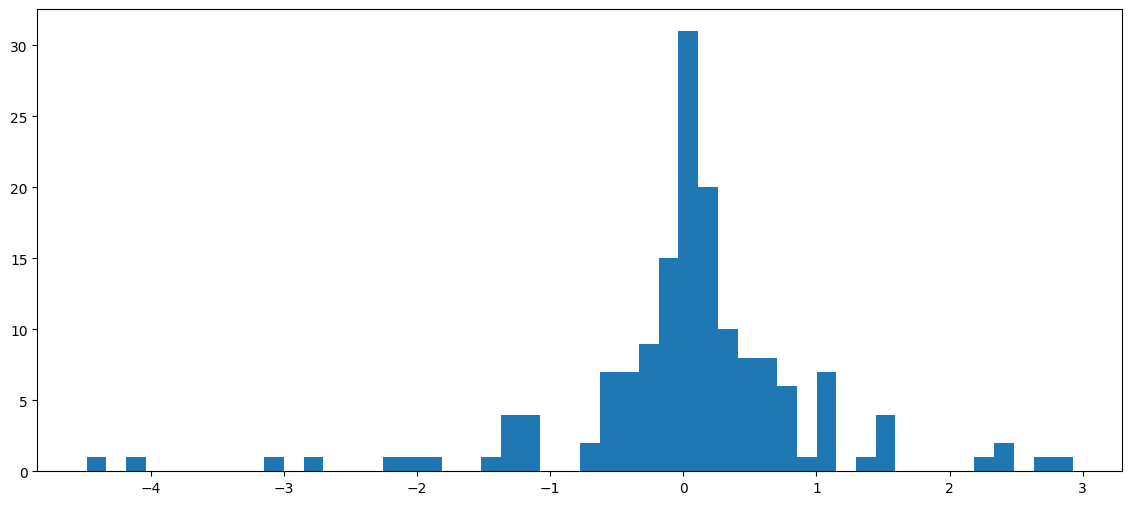

In [25]:
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt

A_H_data = np.load("../Group 1 Full Loop Code/exoplanetAH_data.npy")
Temps = np.unique( np.load("../Group 1 Full Loop Code/exoplanetTg_data.npy")[:,0])
gravities = np.unique( np.load("../Group 1 Full Loop Code/exoplanetTg_data.npy")[:,1])
interp = RegularGridInterpolator(
        (Temps, gravities),
        A_H_data,
        method='linear',
        bounds_error=False,
        fill_value=None
    )

B_H_data =pd.read_csv(r"C:\Users\Miles\OneDrive\Documents\uni stuff\Year 3\Group studies\Group-Studies---Exoplanets\Code\Data\results_2026_02_20__16_44.csv", comment='#')
A_H_data = pd.read_csv(r"C:\Users\Miles\OneDrive\Documents\uni stuff\Year 3\Group studies\Group-Studies---Exoplanets\Group 1 Full Loop Code\165 planets data\pandexo csv files\results20260212_163633.csv", comment='#')
Planet_data= pd.read_csv('Data/planets.csv', comment='#')
planet_names = B_H_data.iloc[:, 0].values  # convert to numpy array
T_eq = B_H_data.iloc[:, 1].values

# Use .isin() to match multiple planet names, then reindex to match the order in B_H_data
g_lookup = Planet_data.set_index('pl_name')['g_planet_cgs']
g = np.array([g_lookup[name] for name in planet_names]) * 0.01

# Stack into (N, 2) array of [T_eq, g] pairs for the interpolator
points = np.column_stack((T_eq, g))
fudge_factors = interp(points)
#print(fudge_factors)
a= np.array(B_H_data.iloc[:,5])- np.array(A_H_data.iloc[:,5])/fudge_factors
mask = np.abs(a)<6 
a= a[mask]
#print(np.argmax(a))
#print(planet_names[75],B_H_data.iloc[75,5] , A_H_data.iloc[75,5], fudge_factors[75], A_H_data.iloc[75,5]/ fudge_factors[75])
plt.figure(figsize= (14,6))
plt.hist(a, bins= 50)
plt.show()


8 87
HD 191939 c L 98-59 d


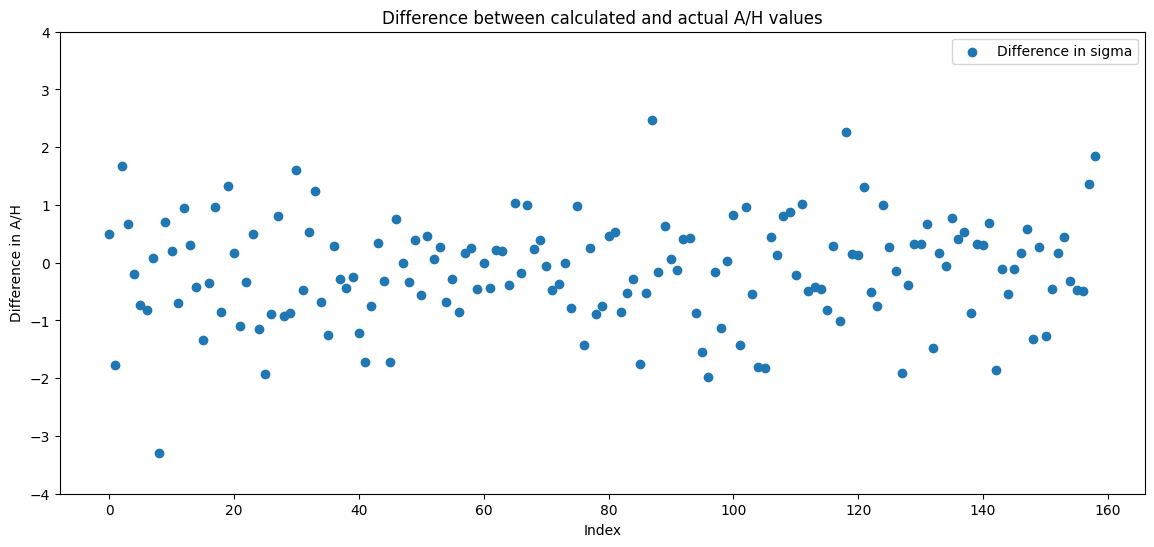

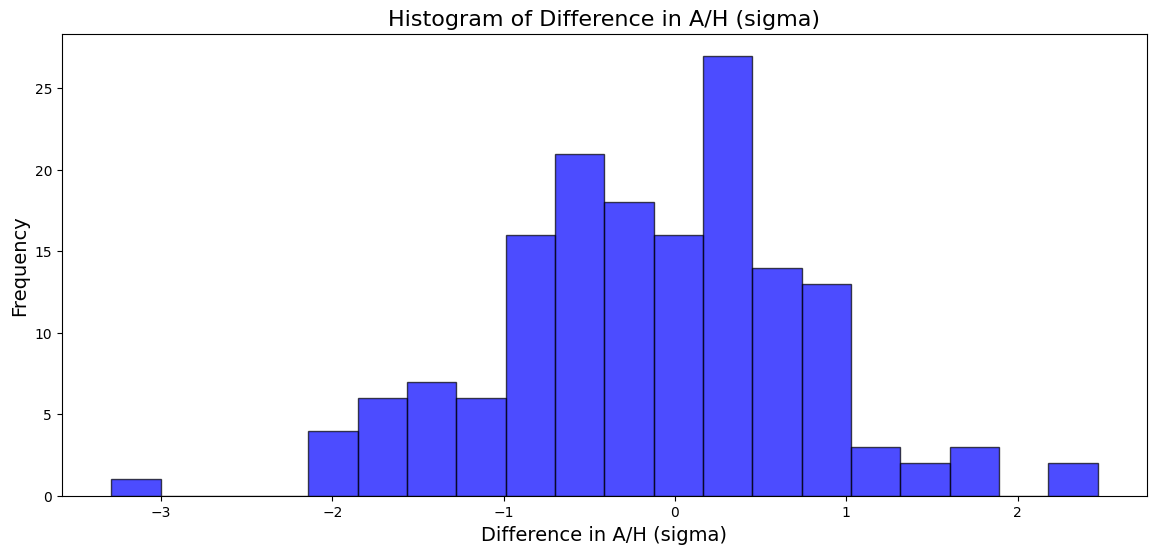

In [ ]:
results_from_data = pd.read_csv(r'C:\Users\Miles\OneDrive\Documents\uni stuff\Year 3\Group studies\Group-Studies---Exoplanets\Group 1 Full Loop Code\165 planets data\pandexo csv files\results20260205_175059.csv')
Actual_values = pd.read_csv(r'C:\Users\Miles\OneDrive\Documents\uni stuff\Year 3\Group studies\Group-Studies---Exoplanets\Code\159_planets_all_columns_with_AH.csv')
Data_A_H = results_from_data.iloc[:,3]

Actual_A_H = Actual_values['A/H']
diffence = Data_A_H - Actual_A_H
diffence_sigma = diffence/ results_from_data.iloc[:,4]
x= np.arange(len(Data_A_H))
print(np.argmin(diffence_sigma), np.argmax(diffence_sigma))
print(results_from_data.iloc[np.argmin(diffence_sigma),0], results_from_data.iloc[np.argmax(diffence_sigma),0]  )
plt.figure(figsize=(14,6))
plt.ylim(-4,4)
plt.scatter(x, diffence_sigma, label='Difference in sigma')
plt.xlabel('Index')
plt.ylabel('Difference in A/H')
plt.title('Difference between calculated and actual A/H values')
plt.legend()
plt.show()


plt.figure(figsize=(14,6))
plt.hist(diffence_sigma, bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('residual (sigma)', fontsize=14)    
plt.ylabel('Frequency', fontsize=14)
plt.title('Histogram of Difference in A/H (sigma)', fontsize=16)
plt.show()

PearsonRResult(statistic=np.float64(-0.06649989424611366), pvalue=np.float64(0.4049361189807677))


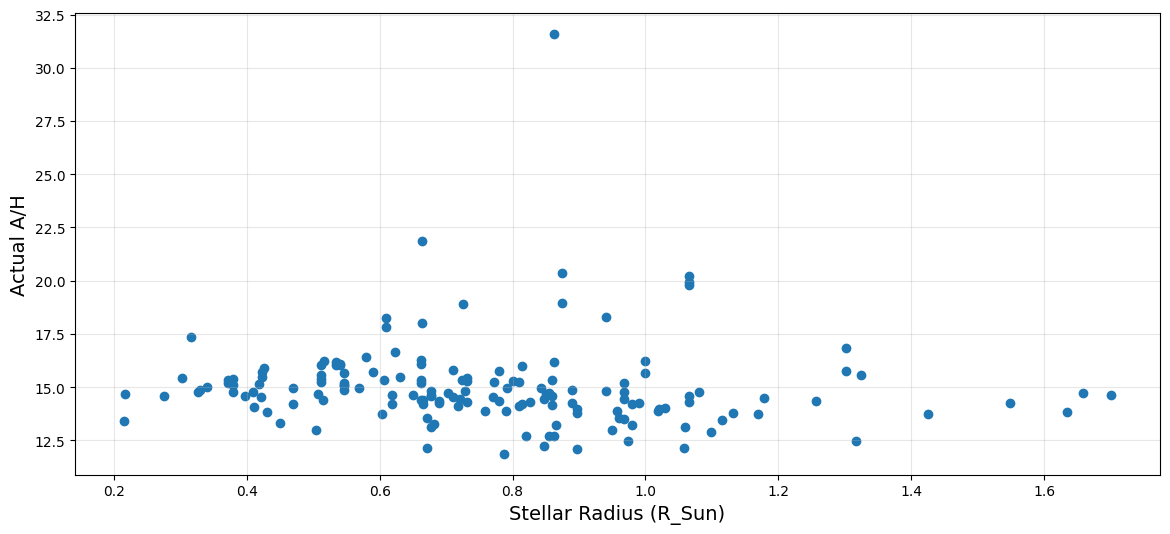

In [ ]:
Actual_values = pd.read_csv(r'C:\Users\Miles\OneDrive\Documents\uni stuff\Year 3\Group studies\Group-Studies---Exoplanets\Code\159_planets_all_columns_with_AH.csv')
Actual_A_H = Actual_values['A/H']
R_S= Actual_values['st_rad']
R= stats.pearsonr(R_S, Actual_A_H)
print(R)
plt.figure(figsize=(14,6))
plt.scatter(R_S, Actual_A_H, label='Actual A/H')
plt.xlabel('Stellar Radius (R_Sun)', fontsize=14)
plt.ylabel('Actual A/H', fontsize=14)
plt.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.8)
plt.grid(True, which='minor', alpha=0.15, linestyle=':', linewidth=0.5)
plt.show()

PearsonRResult(statistic=np.float64(-0.2699740043065058), pvalue=np.float64(0.0005784692882490272))


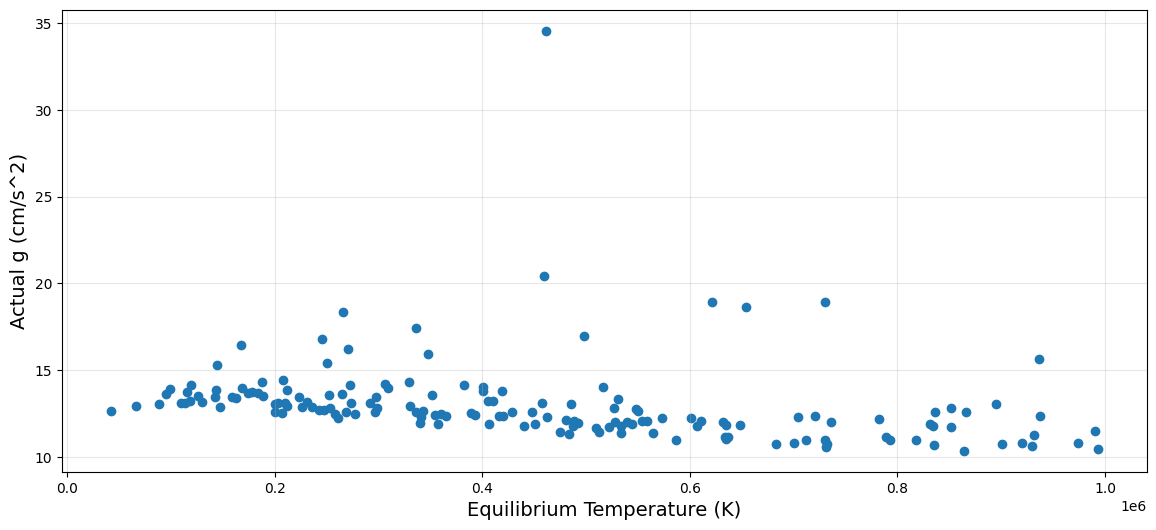

In [10]:
Actual_values = pd.read_csv(r'C:\Users\Miles\Documents\group studies\Group-Studies---Exoplanets\Code\159_planets_all_columns_with_final_co2_A_H.csv')
Actual_A_H = Actual_values['A_H']
T_eq= Actual_values['pl_Teq']
R= stats.pearsonr(T_eq**2, Actual_A_H)
print(R)
plt.figure(figsize=(14,6))
plt.scatter(T_eq**2, Actual_A_H, label='Actual g')
plt.xlabel('Equilibrium Temperature (K)', fontsize=14)
plt.ylabel('Actual g (cm/s^2)', fontsize=14)
plt.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.8)
plt.grid(True, which='minor', alpha=0.15, linestyle=':', linewidth=0.5)
plt.show()

PearsonRResult(statistic=np.float64(0.8320949337672093), pvalue=np.float64(4.9073246030043004e-42))


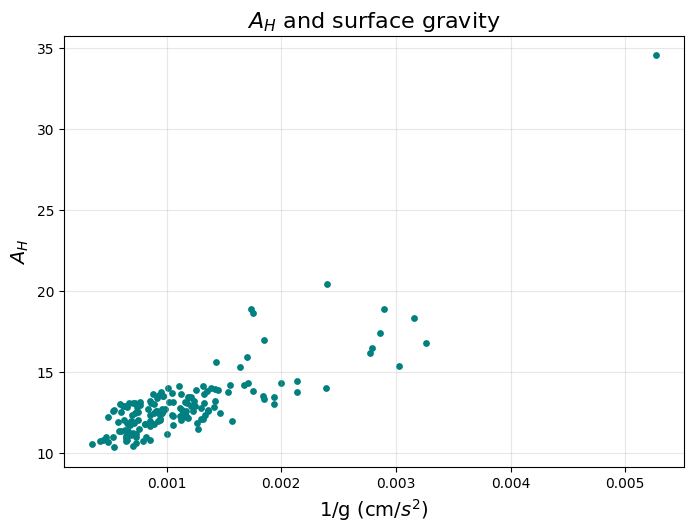

In [9]:
Actual_values = pd.read_csv(r'C:\Users\Miles\Documents\group studies\Group-Studies---Exoplanets\Code\159_planets_all_columns_with_final_co2_A_H.csv')
Actual_A_H = Actual_values['A_H']
g= Actual_values['g_planet_cgs']
R= stats.pearsonr(1/g, Actual_A_H)
print(R)
plt.figure(figsize=(8, 5.6))
plt.title("$A_H$ and surface gravity", fontsize=16)
plt.scatter(1/g, Actual_A_H, label='$A_H$',color='teal', s=15)
plt.xlabel('1/g (cm/$s^2$)', fontsize=14)
plt.ylabel('$A_H$', fontsize=14)
plt.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.8)
plt.grid(True, which='minor', alpha=0.15, linestyle=':', linewidth=0.5)
plt.show()

PearsonRResult(statistic=np.float64(-0.2527794593144339), pvalue=np.float64(0.0013060406937246863))


C:\Users\Miles\AppData\Local\Temp\ipykernel_27244\2620027605.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


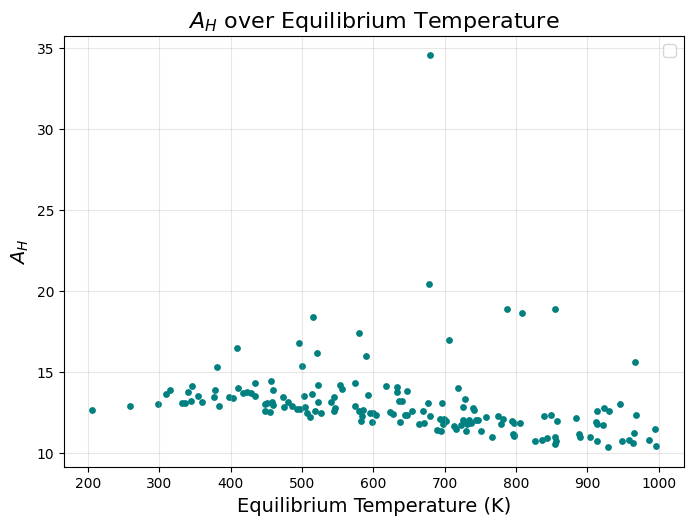

In [11]:
Actual_values = pd.read_csv(r'C:\Users\Miles\Documents\group studies\Group-Studies---Exoplanets\Code\159_planets_all_columns_with_final_co2_A_H.csv')
Actual_A_H = Actual_values['A_H']
Rad = Actual_values['pl_Teq']
R = stats.pearsonr(Rad, Actual_A_H)
print(R)


x_line = np.linspace(Rad.min(), Rad.max(), 300)

plt.figure(figsize=(8, 5.6))
plt.scatter(Rad, Actual_A_H, color='teal', s= 15)

#plt.ylim(12, 20)
plt.title('$A_H$ over Equilibrium Temperature', fontsize=16)
plt.xlabel('Equilibrium Temperature (K)', fontsize=14)
plt.ylabel('$A_H$', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.8)
plt.grid(True, which='minor', alpha=0.15, linestyle=':', linewidth=0.5)
plt.show()